# 02 — Stage A: heuristic funnel labels

Strategy: pull labels from multiple weak signals (audience, objective, optimization_event,
ad_format, campaign_name). Combine by majority vote; require multi-signal agreement
for `confident` labels, single-signal for `weak`. Save labels + confidence for Stage B.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df = pd.read_csv("campaigns_unlabeled.csv")

# Aggregate to campaign level (config is constant per campaign_id)
config_cols = ["campaign_id", "customer_id", "platform", "campaign_name", "objective",
               "bidding_strategy", "optimization_event", "ad_format", "audience_type", "daily_budget_usd"]
camps = df[config_cols].drop_duplicates("campaign_id").reset_index(drop=True)
print("campaigns:", len(camps))
camps.head()


campaigns: 637


,campaign_id,customer_id,platform,campaign_name,objective,bidding_strategy,optimization_event,ad_format,audience_type,daily_budget_usd
0,CMP-00001,CUST-0001,google_ads,Product launch New users Aug,Website traffic,Maximize clicks,Conversions,Responsive search,remarketing,127.37
1,CMP-00002,CUST-0001,google_ads,Cold audience A/B,Brand awareness and reach,CPM,Impressions,Video - Non-skippable,broad,641.07
2,CMP-00003,CUST-0001,tiktok_ads,EU,Traffic,CPC,Video views (6s),Spark Ad,lookalike_small,372.54
3,CMP-00004,CUST-0001,google_ads,Spring sale - Retargeting - A/B,Sales,Maximize conversion value,Conversion value,Dynamic search,remarketing,321.50
4,CMP-00005,CUST-0001,google_ads,Lower funnel 1,Website traffic,Target ROAS,Conversions,Responsive search,lookalike_small,165.59


## Signal definitions

In [2]:
# --- audience signal ---
AUD_TOP = {"broad", "affinity", "lookalike_large"}
AUD_BOTTOM = {"remarketing", "customer_list"}
# in_market, lookalike_small intentionally ambiguous

def audience_signal(a):
    if a in AUD_TOP: return "top"
    if a in AUD_BOTTOM: return "bottom"
    return None

# --- objective signal (substring match, lowercase) ---
OBJ_TOP_KW = ["awareness", "reach", "video view", "brand"]
OBJ_BOTTOM_KW = ["conversion", "sales", "lead", "purchase", "traffic", "app install"]
# "Website traffic" is mid-funnel-ish, putting in bottom is too aggressive — we'll handle below

def objective_signal(o):
    o = str(o).lower()
    top_hit = any(k in o for k in OBJ_TOP_KW)
    bot_hit = any(k in o for k in ["conversion", "sales", "lead", "purchase"])  # strict bottom
    if top_hit and not bot_hit: return "top"
    if bot_hit and not top_hit: return "bottom"
    return None

# --- optimization_event signal ---
OPT_TOP_KW = ["impression", "reach", "view", "thruplay", "awareness"]
OPT_BOTTOM_KW = ["purchase", "lead", "conversion", "sign up", "signup", "add to cart", "complete registration"]

def optim_signal(o):
    o = str(o).lower()
    top_hit = any(k in o for k in OPT_TOP_KW)
    bot_hit = any(k in o for k in OPT_BOTTOM_KW)
    if top_hit and not bot_hit: return "top"
    if bot_hit and not top_hit: return "bottom"
    return None

# --- ad_format signal ---
FMT_TOP_KW = ["video", "in-stream", "in-feed video", "story", "spark", "topview"]
FMT_BOTTOM_KW = ["lead gen", "lead form", "dynamic product", "collection", "shopping", "catalog"]

def format_signal(f):
    f = str(f).lower()
    top_hit = any(k in f for k in FMT_TOP_KW)
    bot_hit = any(k in f for k in FMT_BOTTOM_KW)
    if top_hit and not bot_hit: return "top"
    if bot_hit and not top_hit: return "bottom"
    return None

# --- campaign_name signal ---
STOPWORDS = {"the","a","an","and","or","for","of","to","in","on","with","new",
             "jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec",
             "campaign","ad","ads"}
NAME_TOP = {"awareness","reach","prospecting","launch","brand","tof","upper","awareness"}
NAME_BOTTOM = {"retarget","retargeting","remarketing","conversion","conversions","purchase",
               "sales","lead","leads","bof","bottom","branded","cart","checkout","intent"}

def name_signal(name):
    toks = set(re.findall(r"[a-z]+", str(name).lower())) - STOPWORDS
    top_hit = bool(toks & NAME_TOP)
    bot_hit = bool(toks & NAME_BOTTOM)
    if top_hit and not bot_hit: return "top"
    if bot_hit and not top_hit: return "bottom"
    return None


In [3]:
# Apply signals
camps["sig_audience"] = camps.audience_type.apply(audience_signal)
camps["sig_objective"] = camps.objective.apply(objective_signal)
camps["sig_optim"] = camps.optimization_event.apply(optim_signal)
camps["sig_format"] = camps.ad_format.apply(format_signal)
camps["sig_name"] = camps.campaign_name.apply(name_signal)

# Per-signal coverage
sig_cols = ["sig_audience", "sig_objective", "sig_optim", "sig_format", "sig_name"]
print("Coverage per signal (non-null share):")
print(camps[sig_cols].notna().mean().round(3))
print()
print("Top/bottom per signal:")
for c in sig_cols:
    print(c, ":", camps[c].value_counts(dropna=False).to_dict())


Coverage per signal (non-null share):
sig_audience     0.738
sig_objective    0.711
sig_optim        0.761
sig_format       0.344
sig_name         0.366
dtype: float64

Top/bottom per signal:
sig_audience : {'top': 261, 'bottom': 209, None: 167}
sig_objective : {'bottom': 261, 'top': 192, None: 184}
sig_optim : {'top': 269, 'bottom': 216, None: 152}
sig_format : {None: 418, 'top': 125, 'bottom': 94}
sig_name : {None: 404, 'top': 126, 'bottom': 107}


## Aggregate signals into a label

In [4]:
def vote(row):
    votes = [row[c] for c in sig_cols if pd.notna(row[c])]
    if not votes:
        return pd.Series([None, 0, 0])
    n_top = votes.count("top"); n_bot = votes.count("bottom")
    n_total = n_top + n_bot
    if n_top == n_bot:
        return pd.Series([None, n_top, n_bot])  # conflict
    label = "top" if n_top > n_bot else "bottom"
    return pd.Series([label, n_top, n_bot])

camps[["funnel_label", "n_top_votes", "n_bot_votes"]] = camps.apply(vote, axis=1)
camps["n_signals"] = camps.n_top_votes + camps.n_bot_votes
camps["agreement"] = camps[["n_top_votes", "n_bot_votes"]].max(axis=1) / camps.n_signals.replace(0, np.nan)

# Confidence tier:
#   high: 3+ signals all agreeing, OR 4+ signals with >=80% agreement
#   medium: 2 signals agreeing, OR 3+ signals with mixed but clear majority
#   low: only 1 signal, or conflict
def confidence(row):
    if row.funnel_label is None: return "none"
    if row.n_signals >= 3 and row.agreement == 1.0: return "high"
    if row.n_signals >= 4 and row.agreement >= 0.75: return "high"
    if row.n_signals >= 2 and row.agreement >= 0.66: return "medium"
    return "low"

camps["confidence"] = camps.apply(confidence, axis=1)
print(camps.groupby(["confidence", "funnel_label"]).size())
print()
print("Coverage by confidence tier:")
print(camps.confidence.value_counts(normalize=True).round(3))


confidence  funnel_label
high        bottom          144
            top             194
low         bottom           29
            top              15
medium      bottom          114
            top              88
dtype: int64

Coverage by confidence tier:
high      0.531
medium    0.317
low       0.152
Name: confidence, dtype: float64


## Quality checks

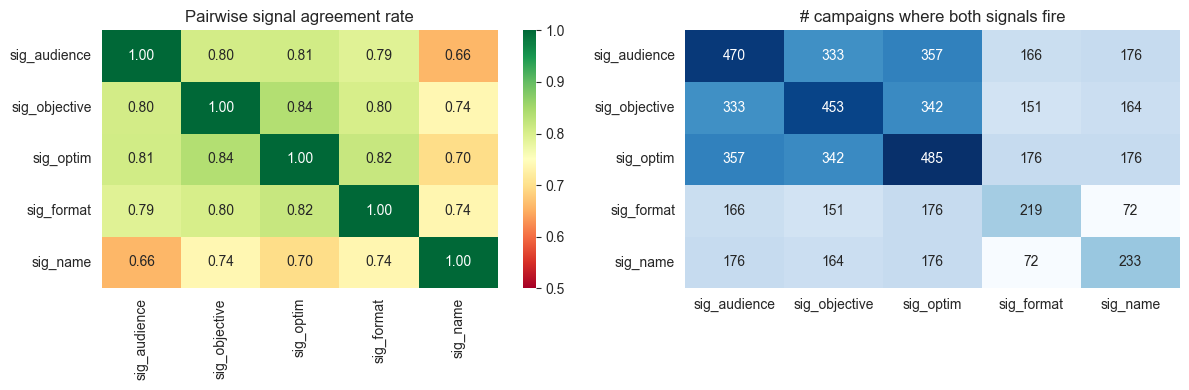

In [5]:
# 1. Pairwise signal agreement matrix (on rows where both signals fire)
def agree_rate(s1, s2):
    sub = camps[[s1, s2]].copy()
    sub.columns = ["a", "b"]
    sub = sub.dropna()
    if len(sub) == 0: return float("nan")
    return float((sub["a"] == sub["b"]).mean())

def overlap_count(s1, s2):
    sub = camps[[s1, s2]].copy()
    sub.columns = ["a", "b"]
    return int(sub.dropna().shape[0])

agree_df = pd.DataFrame(
    [[agree_rate(a, b) for b in sig_cols] for a in sig_cols],
    index=sig_cols, columns=sig_cols, dtype=float,
)
counts_df = pd.DataFrame(
    [[overlap_count(a, b) for b in sig_cols] for a in sig_cols],
    index=sig_cols, columns=sig_cols, dtype=int,
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(agree_df, annot=True, cmap="RdYlGn", vmin=0.5, vmax=1.0, fmt=".2f", ax=axes[0])
axes[0].set_title("Pairwise signal agreement rate")
sns.heatmap(counts_df, annot=True, cmap="Blues", fmt="d", cbar=False, ax=axes[1])
axes[1].set_title("# campaigns where both signals fire")
plt.tight_layout(); plt.show()


In [6]:
# 2. Label distribution per platform — sanity check
ct = pd.crosstab(camps.platform, camps.funnel_label, dropna=False, normalize="index").round(3)
print("Funnel label share per platform:")
print(ct)
print()
ct2 = pd.crosstab(camps.platform, camps.confidence, normalize="index").round(3)
print("Confidence tier share per platform:")
print(ct2)


Funnel label share per platform:
funnel_label  bottom    top
platform                   
google_ads     0.507  0.493
linkedin_ads   0.542  0.458
meta_ads       0.488  0.512
tiktok_ads     0.424  0.576

Confidence tier share per platform:
confidence     high    low  medium
platform                          
google_ads    0.484  0.154   0.362
linkedin_ads  0.422  0.181   0.398
meta_ads      0.623  0.130   0.247
tiktok_ads    0.510  0.176   0.314


In [7]:
# 3. Spot-check: print 10 random high-confidence labels of each class
print("=== HIGH-CONFIDENCE TOP ===")
print(camps[(camps.funnel_label == "top") & (camps.confidence == "high")]
      .sample(min(10, ((camps.funnel_label == "top") & (camps.confidence == "high")).sum()), random_state=0)
      [["campaign_name", "audience_type", "objective", "optimization_event", "ad_format"]])
print()
print("=== HIGH-CONFIDENCE BOTTOM ===")
print(camps[(camps.funnel_label == "bottom") & (camps.confidence == "high")]
      .sample(min(10, ((camps.funnel_label == "bottom") & (camps.confidence == "high")).sum()), random_state=0)
      [["campaign_name", "audience_type", "objective", "optimization_event", "ad_format"]])


=== HIGH-CONFIDENCE TOP ===
                                campaign_name    audience_type  \
344  Back to school | High-value | Top funnel         affinity   
593                  Summer | Brand awareness            broad   
181                          Enterprise - Sep         affinity   
275                       SMB - Cold audience        in_market   
59                                         TF            broad   
130                     Product launch | copy    customer_list   
76                                    Q3 2025  lookalike_large   
391                        Trial - Top funnel            broad   
520                           Q2 2025 TOF A/B         affinity   
41                                 Conversion  lookalike_large   

                       objective optimization_event  \
344  Awareness - Brand awareness        Impressions   
593                 App installs              Reach   
181              Website traffic        Video views   
275  Awareness - Brand aw

In [8]:
# 4. Examine the unlabeled / conflicted ones
print("=== UNLABELED (no signal fired or signals conflict) ===")
mask = camps.funnel_label.isna()
print(f"{mask.sum()} campaigns")
print(camps[mask].sample(min(10, mask.sum()), random_state=0)
      [["campaign_name", "audience_type", "objective", "optimization_event", "ad_format"]])


=== UNLABELED (no signal fired or signals conflict) ===
53 campaigns
                     campaign_name    audience_type        objective  \
540            APAC – Lower funnel         affinity  Website traffic   
359     Black Friday - Webinar - 2        in_market            Unset   
444             Black Friday – A/B            broad    App promotion   
365           Product launch | Sep      remarketing  Brand awareness   
126                 Product launch        in_market            Sales   
22                     Retargeting        in_market   Website visits   
353                   Q1 2025 | DR  lookalike_small   Job applicants   
480                       BOF – v2  lookalike_large            Leads   
330  Back to school - Upper funnel      remarketing            Reach   
294                Spring sale | 2  lookalike_small          Traffic   

     optimization_event          ad_format  
540    Conversion value  Responsive search  
359              Clicks          Discovery  
444

## Save Stage A output

In [9]:
out_cols = ["campaign_id", "customer_id", "platform", "campaign_name", "objective",
            "bidding_strategy", "optimization_event", "ad_format", "audience_type", "daily_budget_usd",
            "funnel_label", "confidence", "n_signals", "agreement"]
camps[out_cols].to_csv("campaigns_stage_a.csv", index=False)
print("Saved campaigns_stage_a.csv with", len(camps), "rows")
print()
print("Final coverage:")
print(f"  labeled (any confidence): {camps.funnel_label.notna().mean():.1%}")
print(f"  high confidence:          {(camps.confidence == 'high').mean():.1%}")
print(f"  medium confidence:        {(camps.confidence == 'medium').mean():.1%}")


Saved campaigns_stage_a.csv with 637 rows

Final coverage:
  labeled (any confidence): 91.7%
  high confidence:          53.1%
  medium confidence:        31.7%


## Stage A reflections

- **Coverage**: see printout above — should hit ~70%+ depending on signal overlap.
- **Confidence tiers**: only high+medium will go into Stage B training. The point of weak/low confidence is to keep them as Stage B *targets* (things we predict), not as training data.
- **Known weaknesses**:
  - `in_market` and `lookalike_small` audiences are intentionally ambiguous and contribute no audience signal.
  - "Website traffic" objective is mid-funnel — excluded from both top and bottom hit lists.
  - Some platform-specific objectives may slip through. Inspect the "unlabeled" spot-check above and add signals if a clear pattern is missed.
- **Pairwise agreement heatmap** is the key validation: if any two signals disagree more than ~20%, one of them is mis-calibrated and should be tightened.
